<div align=center>

---
# **Hooke & Jeeves metrics comparison**
---

</div>

In [1]:
import numpy as np
import phise
import metrics

# Metrics definition :

Average depth
$$
\frac{\Sigma_i N_i}{B}
$$

Max depth
$$
\frac{\max_i N_i}{B}
$$

Average flux
$$
\Sigma_i N_i
$$

Max flux
$$
\max_i N_i
$$

In [2]:
# Metrics definition

def bound_outputs(outputs):
    bounded_outputs = np.asarray(outputs, dtype=float).copy()
    bounded_outputs[bounded_outputs <= 1] = 1
    return bounded_outputs

def average_depth(outputs):
    bounded_outputs = bound_outputs(outputs)
    return np.sum(bounded_outputs[1:]) / bounded_outputs[0]

def max_depth(outputs):
    bounded_outputs = bound_outputs(outputs)
    return np.max(bounded_outputs[1:]) / bounded_outputs[0]

def average_flux(outputs):
    bounded_outputs = bound_outputs(outputs)
    return np.sum(bounded_outputs[1:])

def max_flux(outputs):
    bounded_outputs = bound_outputs(outputs)
    return np.max(bounded_outputs[1:])

considered_metrics = {
    "sum(Ni)/B": average_depth,
    "max(Ni)/B": max_depth,
    "sum(Ni)": average_flux,
    "max(Ni)": max_flux,
}

In [3]:
# Context definition & data generation

ctx = phise.examples.contexts.get_PHOB()
# ctx.camera.ideal = True

metrics.generate_data(ctx, metrics=considered_metrics, samples=1000)

Hooke and Jeeves metric runs (1000 samples x 4 metrics):   0%|          | 0/4000 [00:04<?, ?it/s]


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

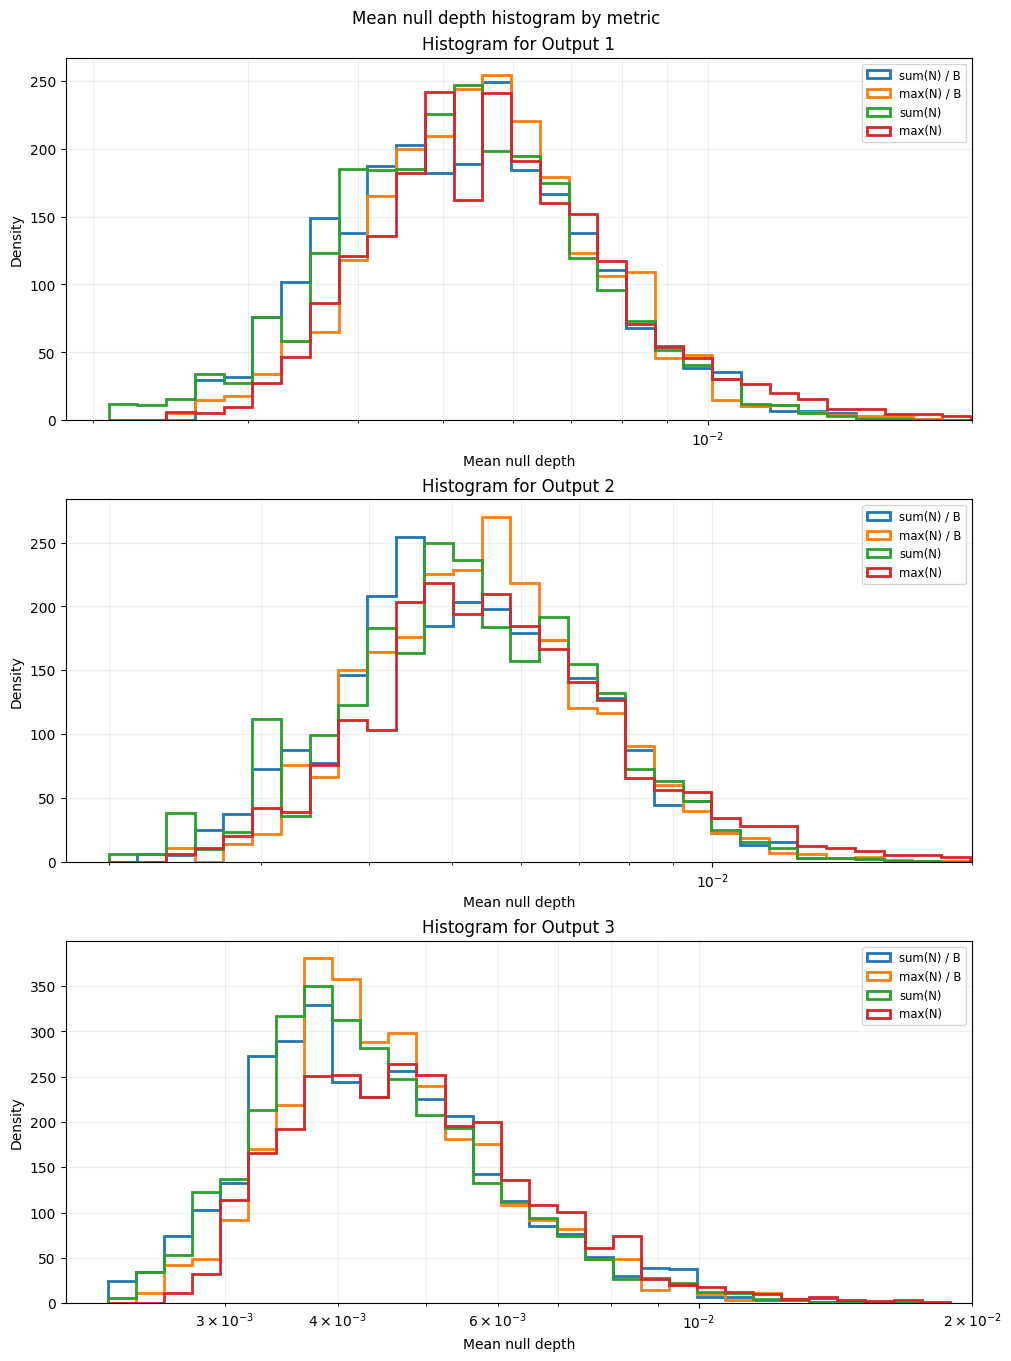

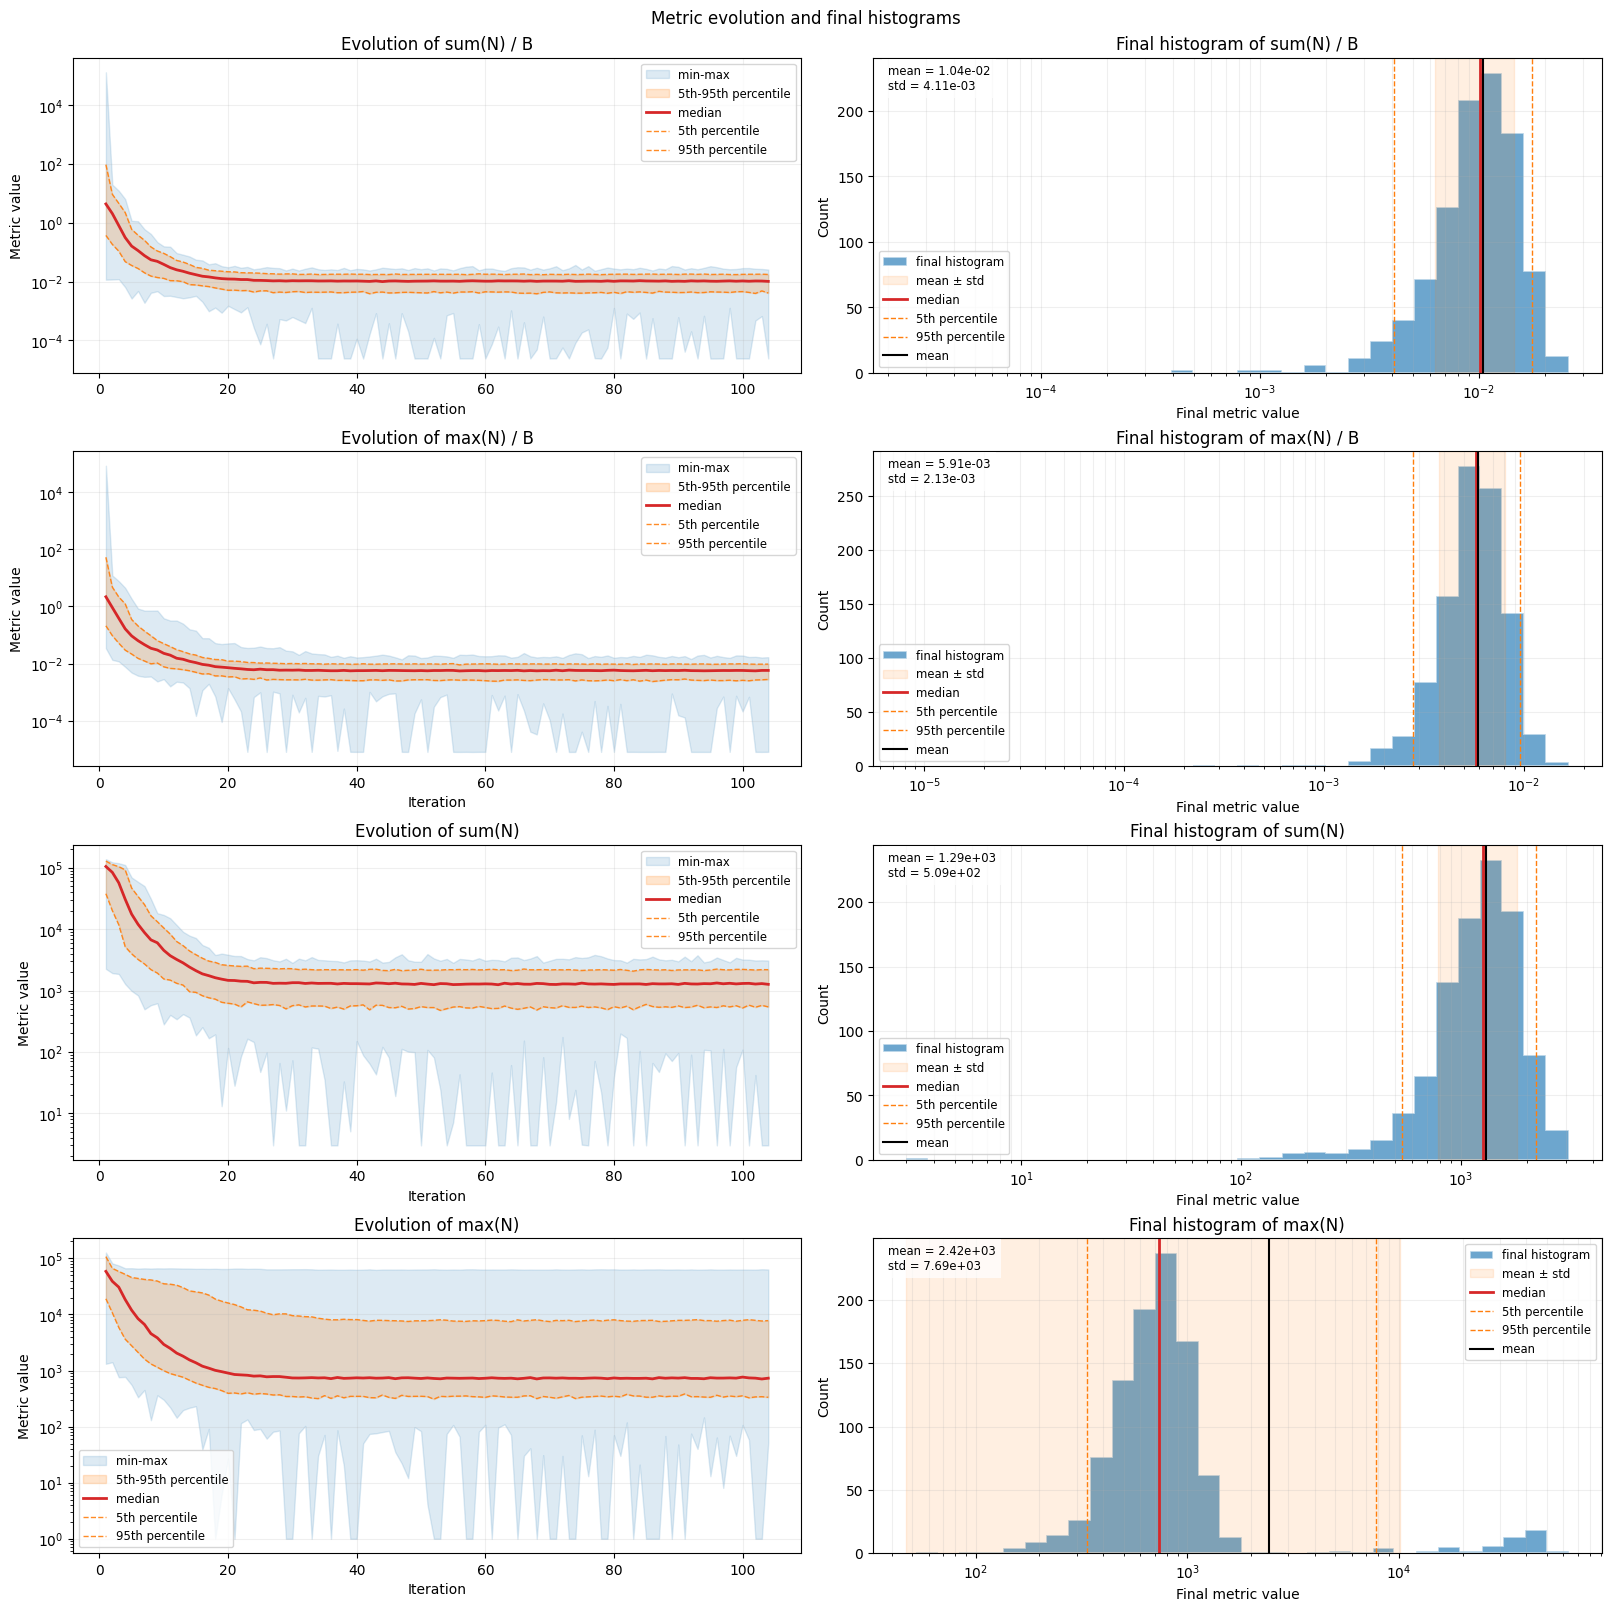

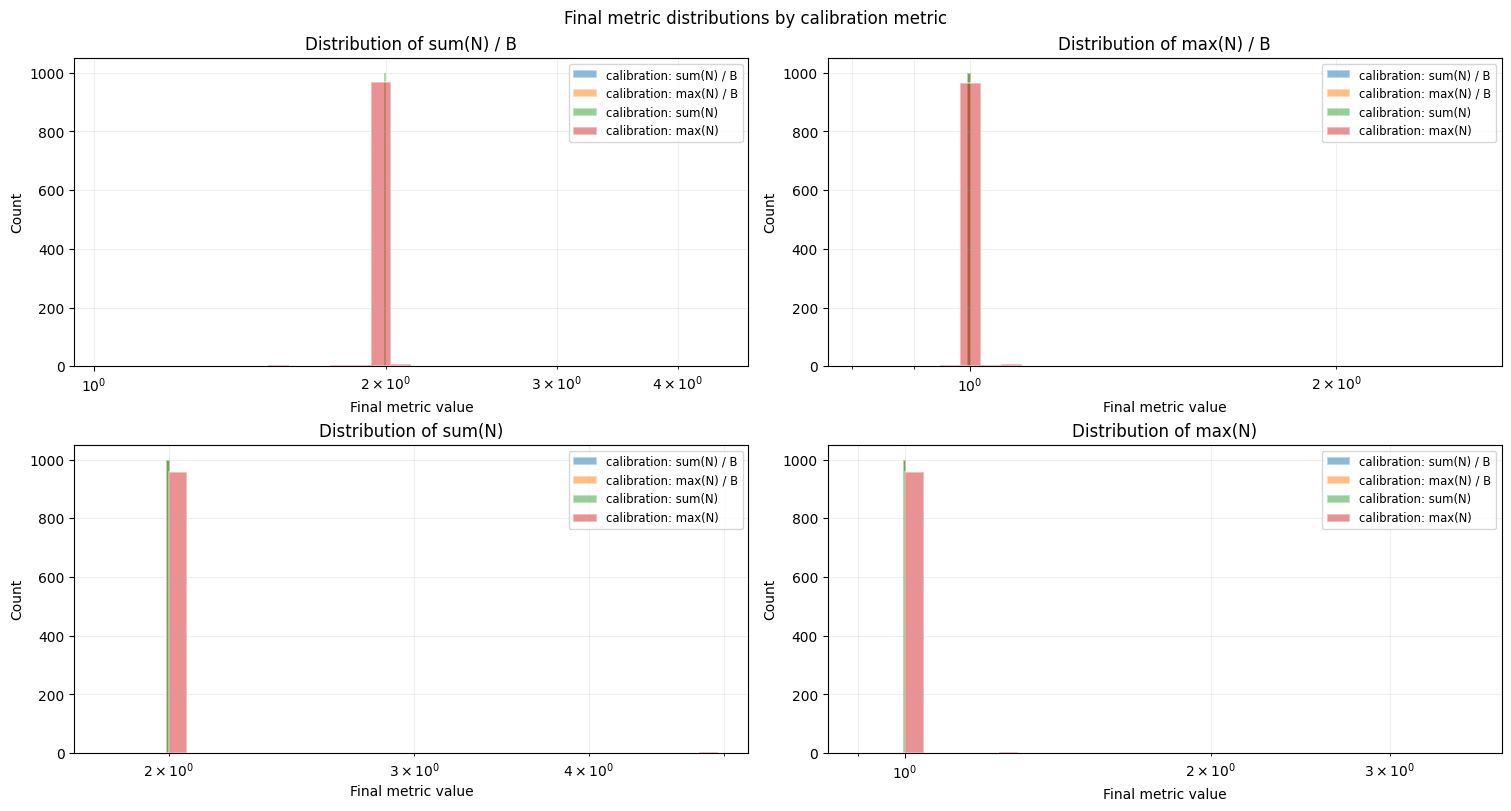

,Metric,Output 1,Output 2,Output 3,Total
0,sum(N) / B,6.27e-03 ± 2.20e-03 | 2.63e-03 - 1.73e-02,6.15e-03 ± 2.11e-03 | 2.30e-03 - 1.77e-02,5.24e-03 ± 2.07e-03 | 2.23e-03 - 2.14e-02,5.89e-03 ± 2.12e-03 | 2.23e-03 - 2.14e-02
1,max(N) / B,6.49e-03 ± 2.76e-03 | 2.58e-03 - 6.14e-02,6.38e-03 ± 2.85e-03 | 2.42e-03 - 6.27e-02,5.31e-03 ± 2.68e-03 | 2.49e-03 - 6.07e-02,6.06e-03 ± 2.76e-03 | 2.42e-03 - 6.27e-02
2,sum(N),6.17e-03 ± 2.10e-03 | 2.08e-03 - 1.70e-02,6.21e-03 ± 2.12e-03 | 2.00e-03 - 1.75e-02,5.11e-03 ± 1.85e-03 | 2.30e-03 - 1.43e-02,5.83e-03 ± 2.03e-03 | 2.00e-03 - 1.75e-02
3,max(N),2.63e-01 ± 1.29e+01 | -3.48e+02 - 1.64e+02,3.31e-01 ± 1.17e+01 | -3.05e+02 - 1.62e+02,2.98e-01 ± 1.05e+01 | -2.56e+02 - 1.63e+02,2.97e-01 ± 1.17e+01 | -3.48e+02 - 1.64e+02


In [ ]:

cache = metrics.generate_metrics_cache(ctx, N=1000)
df = metrics.build_summary_table(cache)
metrics.plot_null_depth_histograms(cache=cache, x_max=2e-2, density=True, histtype="step")
metrics.plot_metric_evolution(cache=cache)
metrics.plot_final_metric_distributions_by_calibration_metric(
    cache=cache,
    density=False,
    histtype="stepfilled",
    x_max=5,
 )
df

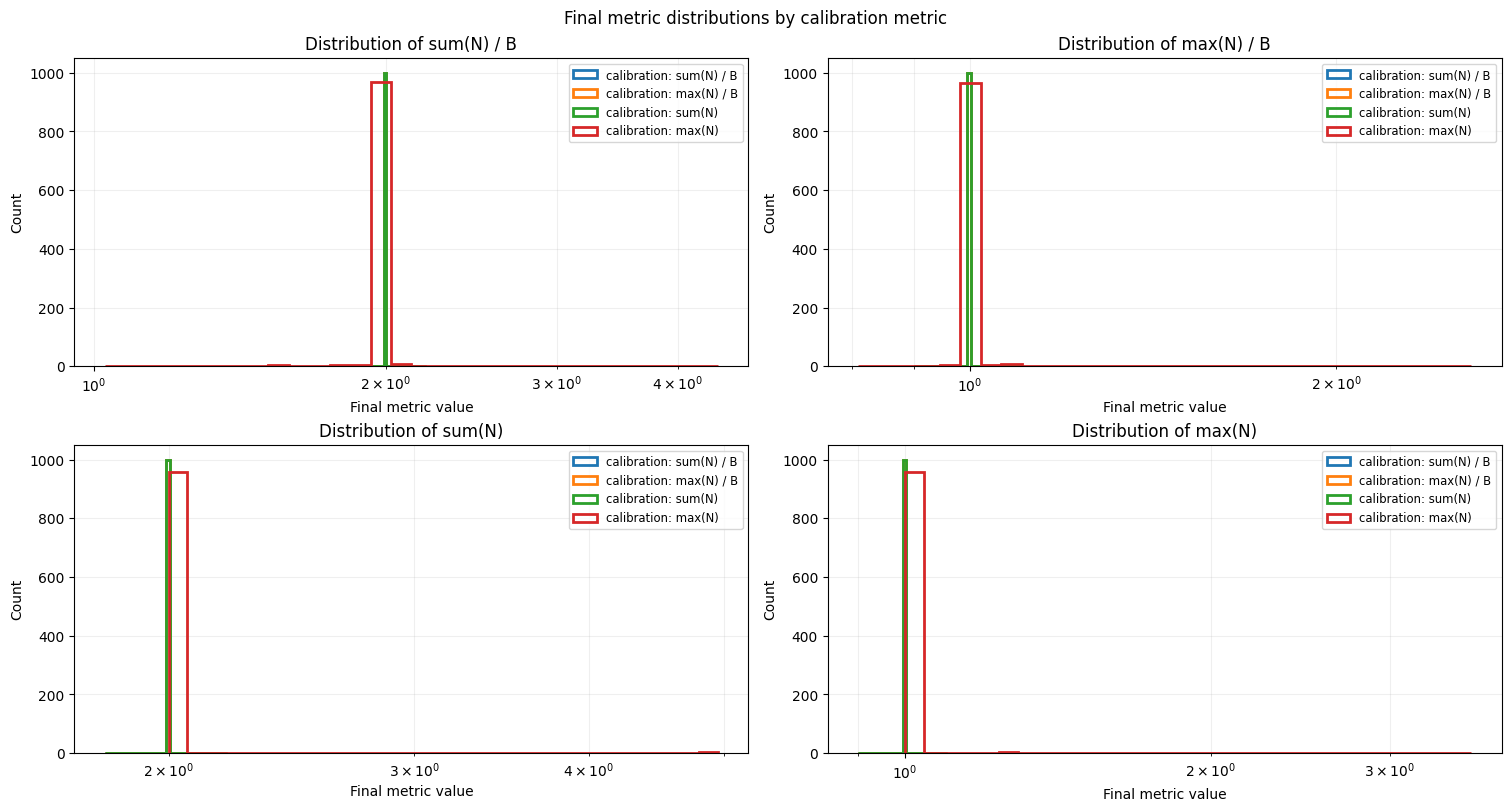

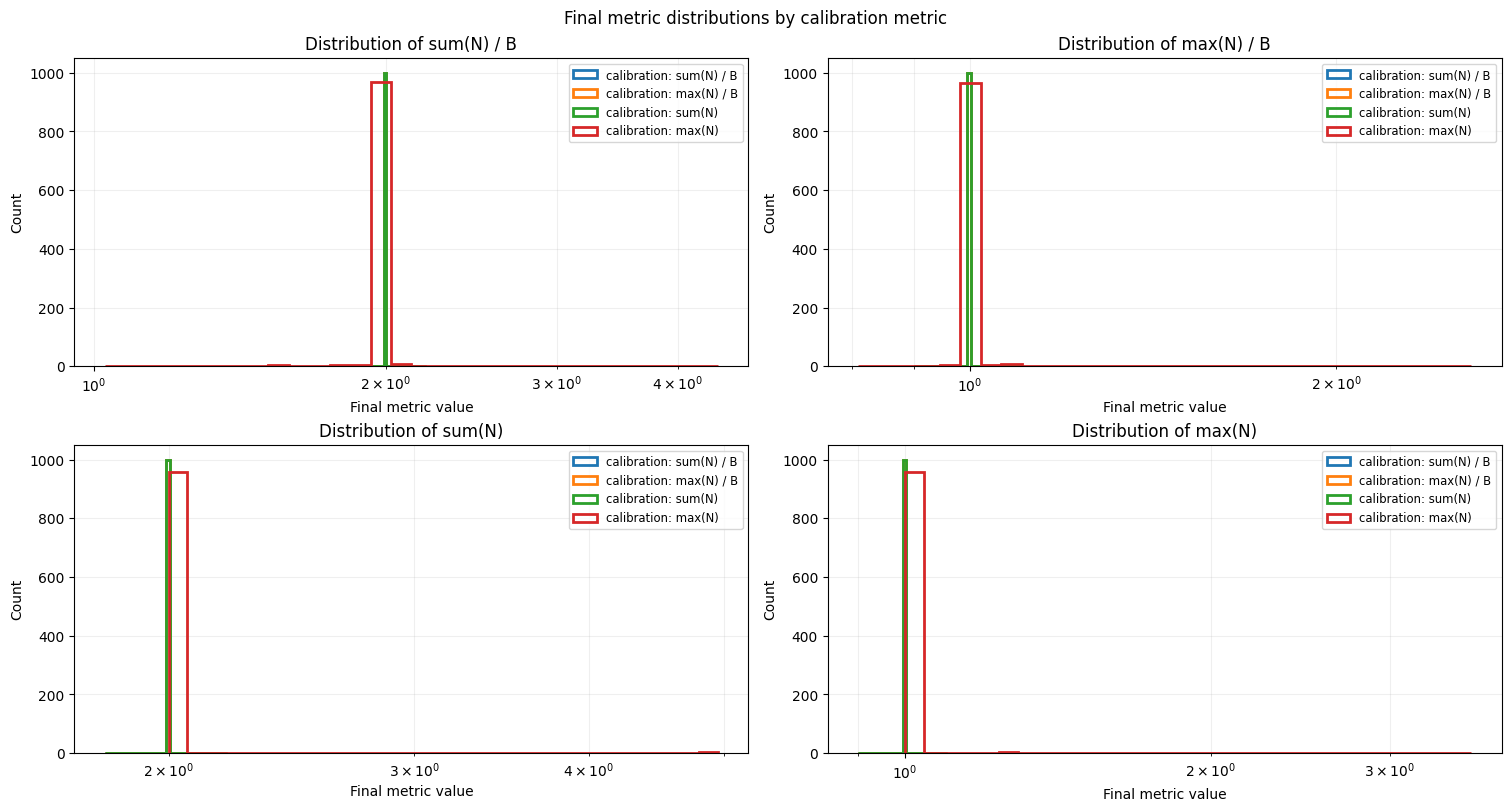

In [6]:
metrics.plot_final_metric_distributions_by_calibration_metric(
    cache=cache,
    density=False,
    x_max=5,
 )